<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/Week14/BERT_Trustworthy_W14D1_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 14. Daily Challenge : Building Trustworthy Insights with BERT

https://octopus.developers.institute/courses/collection/124/course/725/section/1980/chapter/4742

## 0. Importing Libraries

In [1]:
import datasets
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score

## 1. Data Loading & Inspection

Load the tweet_eval dataset (sentiment configuration) via datasets.load_dataset.



In [2]:
dataset = datasets.load_dataset("cardiffnlp/tweet_eval", "sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Print dataset splits and class distribution. Confirm there are 3 labels (negative, neutral, positive).

In [4]:
def print_split_distrib(split):
  print(f'--- Dataset split : {split} ---')
  class_distrib = [0, 0, 0]

  for i in range (0, dataset[split].num_rows):
    i_label = dataset[split][i]['label']
    class_distrib[i_label] += 1

  print(class_distrib)

  for number in range(0, 3):
    print(f'Label {number} : Distribution = {class_distrib[number]/dataset[split].num_rows*100}')

In [5]:
print_split_distrib('train')
print_split_distrib('test')
print_split_distrib('validation')

--- Dataset split : train ---
[7093, 20673, 17849]
Label 0 : Distribution = 15.549709525375425
Label 1 : Distribution = 45.320618217691546
Label 2 : Distribution = 39.12967225693303
--- Dataset split : test ---
[3972, 5937, 2375]
Label 0 : Distribution = 32.33474438293715
Label 1 : Distribution = 48.331162487788994
Label 2 : Distribution = 19.334093129273853
--- Dataset split : validation ---
[312, 869, 819]
Label 0 : Distribution = 15.6
Label 1 : Distribution = 43.45
Label 2 : Distribution = 40.949999999999996


Save two example tweets per label for later visualization.

In [7]:
from collections import defaultdict

examples = defaultdict(list)
target_labels = {0, 1, 2}

for item in dataset["train"]:
    label = item["label"]
    text = item["text"]

    if len(examples[label]) < 2:
        examples[label].append(text)

    # select 2 examples for each label
    if all(len(examples[l]) == 2 for l in target_labels):
        break

label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

for label, texts in examples.items():
    print(f"{label_map[label]}:")
    for t in texts:
        print("-", t)

positive:
- "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
- @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
negative:
- So disappointed in wwe summerslam! I want to see john cena wins his 16th title
- That sucks if you have to take the SATs tomorrow
neutral:
- "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
- Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.


## 2. Tokenization Pipeline

Initialize AutoTokenizer with distilbert-base-uncased.

In [9]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

Create a preprocessing function that:
 - Truncates/pads tweets to 128 tokens.
- Returns input_ids, attention_mask, and labels.

In [12]:
def preprocess(batch):
  enc = tokenizer(batch['text'], max_length=128, padding='max_length', truncation=True)
  enc['labels'] = batch['label']
  return enc

dataset_enc = dataset.map(preprocess, batched=True)

dataset_enc

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2000
    })
})

### TODO : Shuffle the items

Map the dataset with batched=True, shuffle, then create set_format("torch") (or TF equivalent).

In [13]:
dataset_enc = dataset_enc.shuffle(seed=42)

In [17]:
dataset_enc.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

dataset_enc

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2000
    })
})

## 3. Fine-Tuning Setup

Load AutoModelForSequenceClassification with 3 labels.

Use TrainingArguments (epochs=3, batch_size=32, lr=5e-5, weight_decay=0.01).

In [15]:
# Instanciating our model (3 labels)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

training_args = TrainingArguments(num_train_epochs=3,
                                  per_device_train_batch_size=32,
                                  learning_rate=5e-5,
                                  weight_decay=0.01,
                                  load_best_model_at_end=True,
                                  eval_strategy='epoch',
                                  save_strategy='epoch')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

Using device: cuda
CUDA device name: Tesla T4


Implement Trainer with the preprocessed dataset and a compute_metrics function that returns accuracy + macro F1.


In [18]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  accuracy = accuracy_score(y_true=labels, y_pred=predictions)
  macro_f1 = f1_score(y_true=labels, y_pred=predictions, average='macro')
  return {'accuracy': accuracy, 'macro_f1': macro_f1}


In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_enc['train'],
    eval_dataset=dataset_enc['test'],
    compute_metrics=compute_metrics
)



Train and save the best checkpoint (use load_best_model_at_end=True).

In [20]:
trainer_results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.647091,0.660113,0.691387,0.684492
2,0.455947,0.729815,0.683409,0.682639
3,0.270174,0.919322,0.683654,0.682911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


## 4. Evaluation & Calibration

- Evaluate on the validation split; log accuracy and F1.

- Collect the softmax scores for predicted classes on the test split.

- Plot a histogram of confidence scores (bins of 0.1).



In [21]:
val_metrics = trainer.evaluate(dataset_enc['validation'])
val_metrics

{'eval_loss': 0.6270488500595093,
 'eval_accuracy': 0.721,
 'eval_macro_f1': 0.7071115551759733,
 'eval_runtime': 6.8622,
 'eval_samples_per_second': 291.453,
 'eval_steps_per_second': 36.432,
 'epoch': 3.0}

In [22]:
test_predictions = trainer.predict(dataset_enc['test'])
logits = torch.tensor(test_predictions.predictions)
labels = test_predictions.label_ids
probs = torch.softmax(logits, dim=-1).numpy()
max_confidence = probs.max(axis=1)

<function matplotlib.pyplot.show(close=None, block=None)>

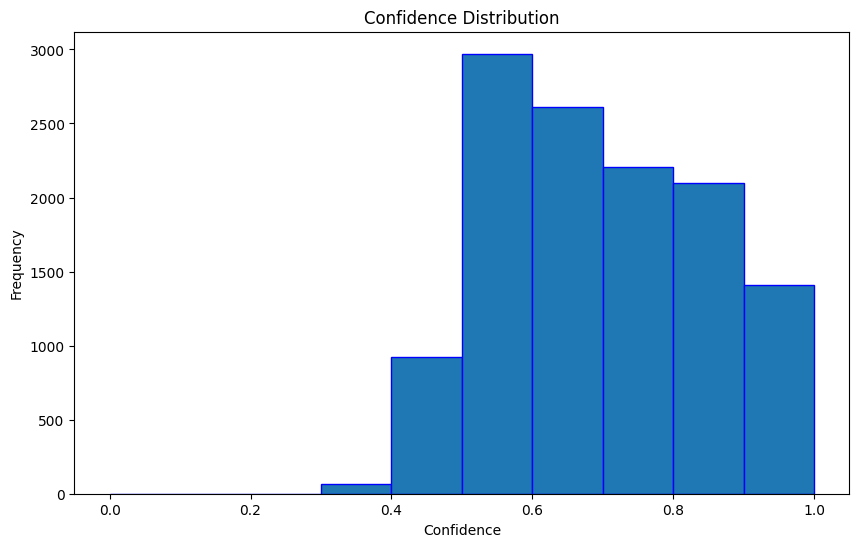

In [23]:
# Plotting the confidence
plt.figure(figsize=(10, 6))
plt.hist(max_confidence, bins=10, range=(0, 1), edgecolor='blue')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.title('Confidence Distribution')
plt.show

- Comment on over/under-confidence trends.

The confidence distribution shows that most predictions fall between 0.6 and 1.0, indicating that the model is generally confident. However, there is also a noticeable number of predictions around 0.5, suggesting uncertainty for some inputs. The model rarely produces very low confidence scores, meaning it tends to commit to a class rather than expressing strong doubt. Overall, the model is moderately confident but not extremely overconfident.

## 5. Attention Inspection

In [42]:
example_tweet = dataset['test'][3]['text']
example_tweet = "I feel terrible, it's so bad, I am sick, and I have a dog!"
example_tweet

"I feel terrible, it's so bad, I am sick, and I have a dog!"

In [43]:
base_model = AutoModel.from_pretrained("distilbert-base-uncased", output_attentions=True)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [44]:
base_model_2 = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", output_attentions=True)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [45]:
# Tokenize our example tweet
example_tweet_enc = tokenizer.encode(example_tweet, return_tensors='pt')
example_tweet_enc

tensor([[ 101, 1045, 2514, 6659, 1010, 2009, 1005, 1055, 2061, 2919, 1010, 1045,
         2572, 5305, 1010, 1998, 1045, 2031, 1037, 3899,  999,  102]])

In [46]:
outputs_1 = base_model(example_tweet_enc)
outputs_2 = base_model_2(example_tweet_enc)

In [48]:
# outputs_1 is from AutoModel, which does not provide classification logits.
# To get a prediction, we need to use outputs_2 from AutoModelForSequenceClassification.

# Extract logits from outputs_2
logits = outputs_2.logits

# Apply softmax to get probabilities (optional, but good for understanding confidence)
probabilities = torch.softmax(logits, dim=-1)

# Get the predicted label using argmax
predicted_label = torch.argmax(logits, dim=-1).item()

print(f"Raw logits: {logits.tolist()}")
print(f"Probabilities: {probabilities.tolist()}")
print(f"Predicted label: {predicted_label}")

Raw logits: [[-0.11434464901685715, -0.016389258205890656]]
Probabilities: [[0.4755306839942932, 0.524469256401062]]
Predicted label: 1


In [49]:
attn_map = outputs_2.attentions[-1]
attn = attn_map

cls_attention = attn[0, :, 0, :].mean(dim=0).detach().numpy()
tokens = tokenizer.convert_ids_to_tokens(example_tweet_enc[0])

cls_attention

array([0.05369893, 0.04484417, 0.01737256, 0.01882699, 0.05121125,
       0.01005327, 0.01702639, 0.01471683, 0.01112406, 0.00924488,
       0.03402003, 0.02088381, 0.01905349, 0.0100587 , 0.16656147,
       0.048809  , 0.03518994, 0.03467652, 0.01691355, 0.01857064,
       0.1512542 , 0.19588931], dtype=float32)

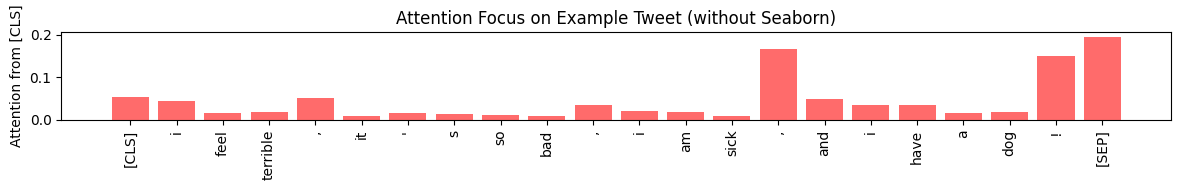

In [50]:
plt.figure(figsize=(12,2))
plt.bar(range(len(tokens)), cls_attention, color="#FF6B6B")
plt.xticks(ticks=range(len(tokens)), labels=tokens, rotation=90)
plt.ylabel("Attention from [CLS]")
plt.title("Attention Focus on Example Tweet (without Seaborn)")
plt.tight_layout()
plt.savefig("attention_example_no_seaborn.png", dpi=200)
plt.show()

The model assigns higher attention to structural tokens like "I" and "and", while sentiment-heavy words like "terrible" receive lower attention from the [CLS] token. This suggests that attention does not directly correspond to word importance. Instead, semantic information from sentiment words may already be integrated in earlier layers or captured by specific attention heads, which gets diluted when averaging across heads.